##Evaluación 3 Big Data
###Análisis de incendios forestales e infraestructura crítica en Chile

Autores: Álvaro Flores - Aurora Mansilla

###Fase 1: Business Understanding

### Contexto

Los incendios forestales representan una amenaza para la infraestructura crítica de salud en Chile. El proyecto busca integrar información histórica de incendios, establecimientos de salud y variables meteorológicas para identificar zonas de riesgo y apoyar la toma de decisiones mediante alertas tempranas.

### Objetivo General

Analizar la evolución de los patrones espaciales y temporales de incendios forestales en Chile mediante técnicas de clustering aplicadas a datos históricos de las temporadas 2002-2003, 2014-2015 y 2019-2020, utilizando la metodología CRISP-DM y una Arquitectura Lambda para el procesamiento de grandes volúmenes de datos.

### Objetivos Específicos

- Analizar el comportamiento histórico de los incendios forestales.
- Integrar información geográfica de infraestructura de salud.
- Incorporar variables meteorológicas relevantes.
- Estimar niveles de riesgo para los establecimientos de salud.
- Visualizar resultados mediante un dashboard.

### Métricas de Éxito
- Precisión del modelo predictivo.
- Tiempo de procesamiento de eventos en tiempo real.
- Capacidad de integrar datos históricos y nuevos registros.
- Calidad de los reportes generados.

###Relación con Arquitectura Lambda

- Batch Layer: almacenamiento y procesamiento de datos históricos.
- Speed Layer: procesamiento de nuevos incendios en tiempo real.
- Serving Layer: consultas y visualización de resultados.

###Fase 2: Data Understanding




**Objetivo de la fase**

Comprender la estructura, calidad y características de los datos históricos de incendios forestales para identificar variables relevantes que permitan detectar patrones y zonas de riesgo mediante técnicas de clustering.

**Propósito de cada rango de años:**

- 2002-2003:	Patrón histórico inicial
- 2014-2015:	Comparación intermedia
- 2019-2020:	Situación reciente

In [40]:
import pandas as pd

df_2002 = pd.read_csv("20022003.csv")
df_2014 = pd.read_csv("20142015.csv")
df_2019 = pd.read_csv("20192020.csv")

print(df_2002.shape)
print(df_2014.shape)
print(df_2019.shape)

(7400, 1)
(8072, 1)
(8125, 1)


In [41]:
df_2002 = pd.read_csv("20022003.csv", sep="|", encoding="latin1")
df_2002["RegiÃ³n"].value_counts()

,count
RegiÃ³n,
BiobÃ­o,3183
AraucanÃ­a,1536
ValparaÃ­so,1084
Metropolitana,573
Maule,512
O'Higgins,222
Los Lagos,141
Los RÃ­os,74
Coquimbo,72


In [42]:
df_2014 = pd.read_csv("20142015.csv", sep="|", encoding="latin1")
df_2014["RegiÃ³n"].value_counts()

,count
RegiÃ³n,
BiobÃ­o,3667
AraucanÃ­a,1496
ValparaÃ­so,865
Maule,688
Metropolitana,442
Los Lagos,434
O'Higgins,235
Los RÃ­os,149
Coquimbo,53


In [43]:
df_2019= pd.read_csv("20192020.csv", sep="|", encoding="latin1")
df_2019["RegiÃ³n"].value_counts()

,count
RegiÃ³n,
BiobÃ­o,2790
AraucanÃ­a,1800
Maule,1161
ValparaÃ­so,629
Ãuble,482
Metropolitana,416
O'Higgins,402
Los Lagos,155
Los RÃ­os,121


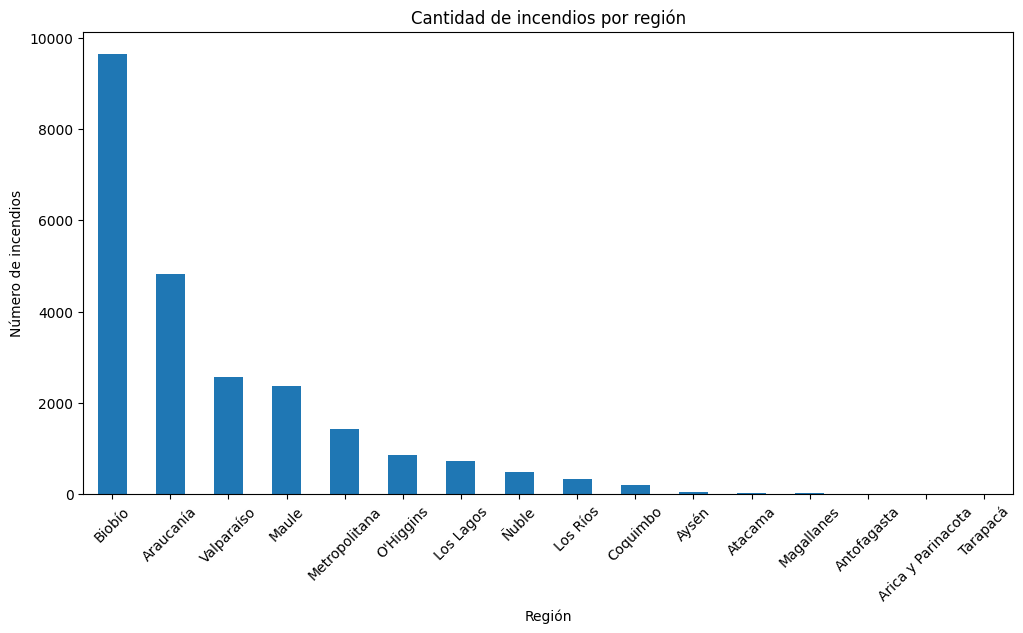

In [44]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.font_manager as fm

df = pd.concat(
    [df_2002, df_2014, df_2019],
    ignore_index=True
)
df = df.rename(columns={'RegiÃ³n': 'Región'})

df['Región'] = df['Región'].apply(lambda x: x.encode('latin1').decode('utf8') if isinstance(x, str) else x)


incendios_region = (
    df.groupby("Región")
      .size()
      .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

incendios_region.plot(kind="bar")

plt.title("Cantidad de incendios por región")
plt.xlabel("Región")
plt.ylabel("Número de incendios")

plt.xticks(rotation=45)
plt.show()

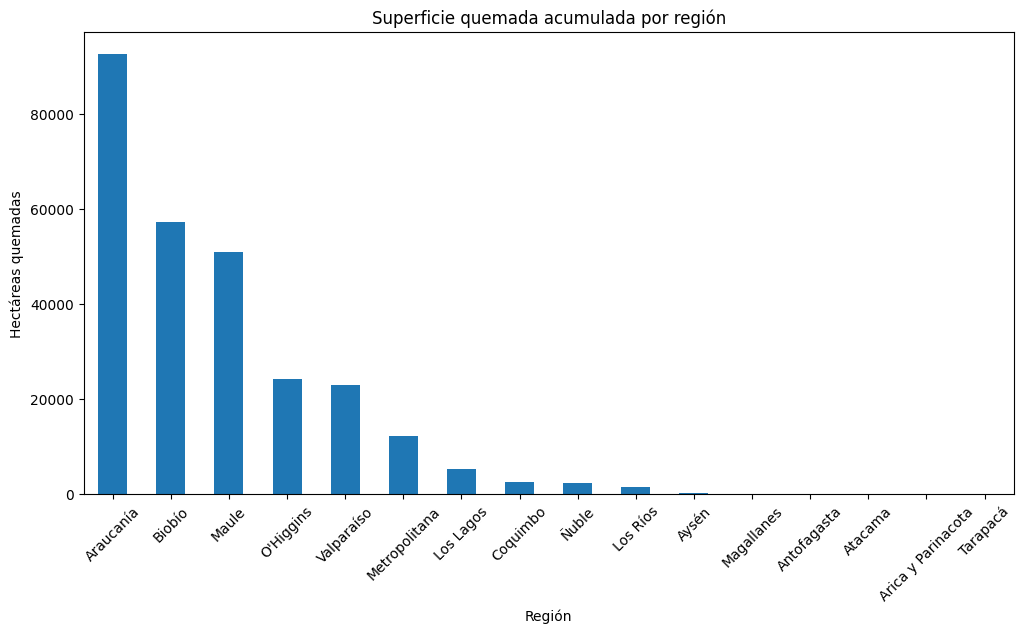

In [45]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.font_manager as fm

superficie_region = (
    df.groupby("Región")
      ["Superficie quemada total [ha]"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

superficie_region.plot(kind="bar")

plt.title("Superficie quemada acumulada por región")
plt.xlabel("Región")
plt.ylabel("Hectáreas quemadas")

plt.xticks(rotation=45)
plt.show()

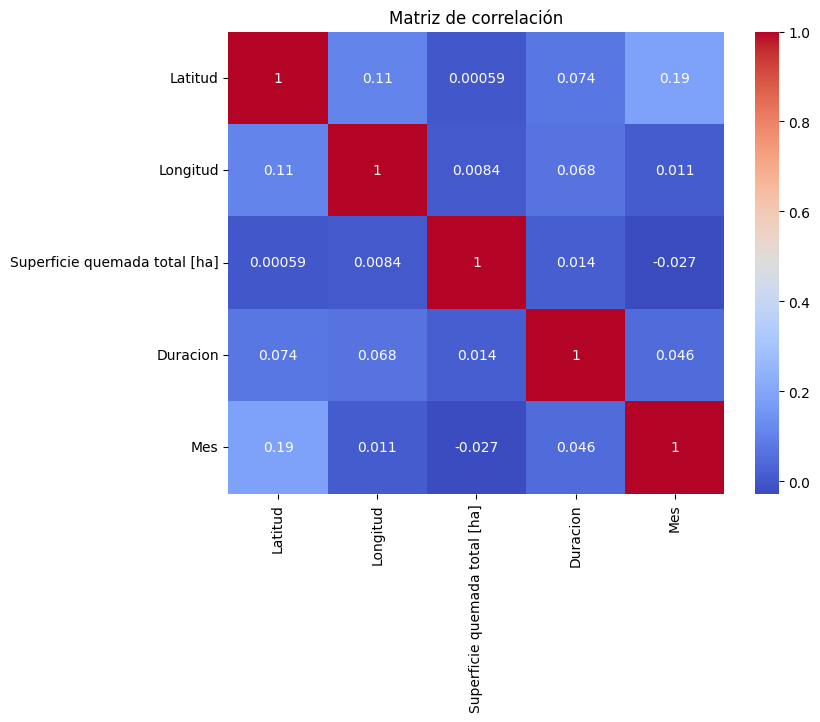

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

df = df.rename(columns={'DuraciÃ³n (minutos)': 'Duracion'})

df["Fecha"] = pd.to_datetime(df["Fecha"], errors="coerce")
df["Mes"] = df["Fecha"].dt.month

variables = df[
    [
        "Latitud",
        "Longitud",
        "Superficie quemada total [ha]",
        "Duracion",
        "Mes"
    ]
]

plt.figure(figsize=(8,6))

sns.heatmap(
    variables.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Matriz de correlación")
plt.show()

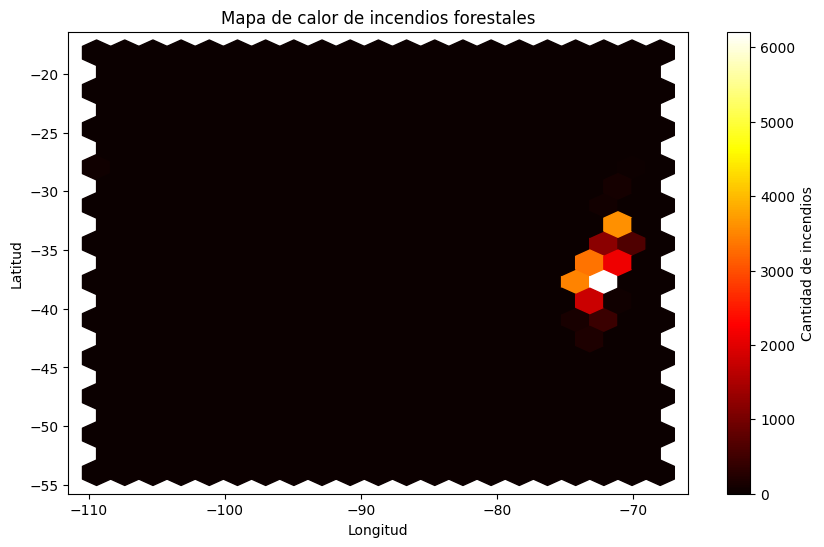

In [47]:
plt.figure(figsize=(10,6))

plt.hexbin(
    df["Longitud"],
    df["Latitud"],
    gridsize=20,
    cmap="hot"
)

plt.colorbar(label="Cantidad de incendios")

plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.title("Mapa de calor de incendios forestales")

plt.show()

###Fase 3: Data Preparation

In [48]:
df = pd.concat(
    [df_2002, df_2014, df_2019],
    ignore_index=True
)

In [38]:
df = df.rename(columns={'Duración (minutos)': 'Duracion'})

In [49]:
df = df.drop_duplicates()

In [50]:
df = df.dropna(
    subset=[
        "Latitud",
        "Longitud",
        "Superficie quemada total [ha]"
    ]
)

In [51]:
df["Fecha"] = pd.to_datetime(
    df["Fecha"],
    errors="coerce"
)

In [52]:
df["Año"] = df["Fecha"].dt.year
df["Mes"] = df["Fecha"].dt.month

In [39]:
X = df[
    [
        "Latitud",
        "Longitud",
        "Superficie quemada total [ha]",
        "Duracion",  # ✅ Ahora SÍ existe
        "Mes"
    ]
]

In [53]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

###Relación con Arquitectura Lambda
- **Batch Layer**

- Datos históricos 2002-2003.
- Datos históricos 2014-2015.
- Datos históricos 2019-2020.
- **Speed Layer**

- Nuevos registros de incendios futuros.
- **Serving Layer**

- Consulta de zonas de riesgo detectadas.

###Fase 4: Modelado

###DBSCAN, K-Means y Agglomerative Clustering

In [54]:
from sklearn.cluster import DBSCAN

modelo = DBSCAN(
    eps=0.3,
    min_samples=10
)

clusters = modelo.fit_predict(X_scaled)

In [55]:
df["Cluster"] = clusters

In [56]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

modelo = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

labels = modelo.fit_predict(X_scaled)


In [57]:
from sklearn.cluster import AgglomerativeClustering

modelo = AgglomerativeClustering(
    n_clusters=5
)

labels = modelo.fit_predict(X_scaled)

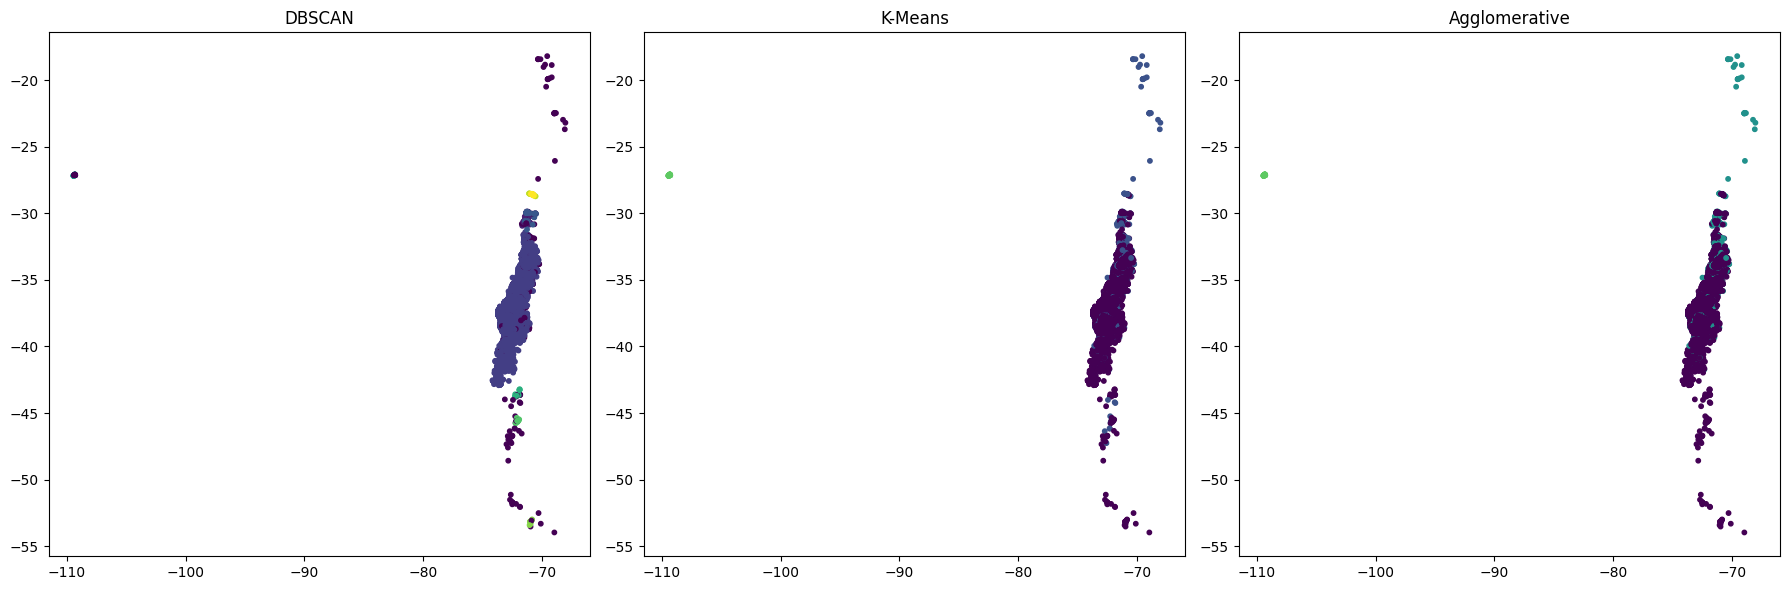

In [58]:
from sklearn.cluster import DBSCAN, KMeans, AgglomerativeClustering

dbscan_labels = clusters

kmeans_model = KMeans(n_clusters=5, random_state=42, n_init=10)
kmeans_labels = kmeans_model.fit_predict(X_scaled)

agg_model = AgglomerativeClustering(n_clusters=5)
agg_labels = agg_model.fit_predict(X_scaled)

fig, ax = plt.subplots(1,3, figsize=(18,6))

ax[0].scatter(
    df["Longitud"],
    df["Latitud"],
    c=dbscan_labels,
    s=10
)
ax[0].set_title("DBSCAN")

ax[1].scatter(
    df["Longitud"],
    df["Latitud"],
    c=kmeans_labels,
    s=10
)
ax[1].set_title("K-Means")

ax[2].scatter(
    df["Longitud"],
    df["Latitud"],
    c=agg_labels,
    s=10
)
ax[2].set_title("Agglomerative")

plt.tight_layout()
plt.show()

###Fase 5: Evaluación

In [36]:
from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score

resultados = []

# DBSCAN
mask = dbscan_labels != -1

if len(set(dbscan_labels[mask])) > 1:
    sil_dbscan = silhouette_score(
        X_scaled[mask],
        dbscan_labels[mask]
    )

    db_dbscan = davies_bouldin_score(
        X_scaled[mask],
        dbscan_labels[mask]
    )

    resultados.append([
        "DBSCAN",
        sil_dbscan,
        db_dbscan
    ])

# KMeans
sil_kmeans = silhouette_score(
    X_scaled,
    kmeans_labels
)

db_kmeans = davies_bouldin_score(
    X_scaled,
    kmeans_labels
)

resultados.append([
    "K-Means",
    sil_kmeans,
    db_kmeans
])

# Agglomerative
sil_agg = silhouette_score(
    X_scaled,
    agg_labels
)

db_agg = davies_bouldin_score(
    X_scaled,
    agg_labels
)

resultados.append([
    "Agglomerative",
    sil_agg,
    db_agg
])



In [37]:
import pandas as pd
metricas = pd.DataFrame(
    resultados,
    columns=["Modelo", "Silhouette", "Davies_Bouldin"]
)

metricas_ordenadas = metricas.sort_values(
    by=["Silhouette", "Davies_Bouldin"],
    ascending=[False, True]
).reset_index(drop=True)

metricas_ordenadas.index += 1

print(metricas_ordenadas)

          Modelo  Silhouette  Davies_Bouldin
1        K-Means    0.536190        0.584368
2  Agglomerative    0.534268        0.437723
3         DBSCAN    0.246705        0.430408


###Fase 6: Despliegue

In [71]:
# ==================== CONFIGURACIÓN INICIAL Y FUNCIONES AUXILIARES ====================
import pandas as pd
import numpy as np
import requests
import logging
import time
import hashlib
import unicodedata
from datetime import datetime, timezone
import warnings
warnings.filterwarnings('ignore')

# Configurar logging para mostrar mensajes en el notebook
logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')

# ====== FUNCIONES DE LIMPIEZA Y NORMALIZACIÓN ======

def limpiar_columna(col: str) -> str:
    """
    Limpia nombres de columnas:
    - Minúsculas
    - Sin tildes ni caracteres especiales
    - Espacios reemplazados por _
    """
    col = str(col).strip().lower()
    # Normalizar (eliminar tildes)
    col = ''.join(c for c in unicodedata.normalize('NFKD', col)
                  if not unicodedata.combining(c))
    # Reemplazar espacios y caracteres especiales
    col = col.replace(' ', '_').replace('á', 'a').replace('é', 'e').replace('í', 'i').replace('ó', 'o').replace('ú', 'u')
    return col

def normalizar_texto(texto) -> str:
    """
    Normaliza texto para comparaciones:
    - Mayúsculas
    - Sin tildes
    - Sin espacios múltiples
    """
    if not isinstance(texto, str):
        return ""
    texto = texto.upper().strip()
    texto = ''.join(c for c in unicodedata.normalize('NFKD', texto)
                    if not unicodedata.combining(c))
    texto = ' '.join(texto.split())
    return texto

def hash_evento(row: pd.Series, columnas: list) -> str:
    """
    Genera un hash único para identificar registros duplicados.
    """
    texto = '|'.join(str(row.get(col, '')) for col in columnas)
    return hashlib.md5(texto.encode('utf-8')).hexdigest()

def primera_columna_existente(df: pd.DataFrame, posibles: list):
    """
    Retorna la primera columna de una lista que exista en el DataFrame.
    """
    for c in posibles:
        if c in df.columns:
            return c
    return None

print("✅ Funciones auxiliares cargadas correctamente")
print(f"Versión de pandas: {pd.__version__}")

✅ Funciones auxiliares cargadas correctamente
Versión de pandas: 2.2.2


In [72]:
# ==================== CONSUMO API WFS: ESTABLECIMIENTOS DE SALUD ====================

# Configuración de la API
GEOPORTAL_WFS_URL = "https://geoportal.cl/geoserver/EstablecimientosdesaluddeChile2025/wfs"
GEOPORTAL_TYPENAME = "EstablecimientosdesaluddeChile2025:establecimientos_de_salud_diciembre_2025"

def descargar_establecimientos_salud(timeout: int = 90) -> pd.DataFrame:
    """
    Descarga establecimientos de salud desde el Geoportal de Chile vía WFS.
    Retorna un DataFrame con los datos crudos.
    """
    params = {
        "service": "WFS",
        "version": "2.0.0",
        "request": "GetFeature",
        "typeName": GEOPORTAL_TYPENAME,
        "outputFormat": "application/json",
    }
    headers = {"User-Agent": "Mozilla/5.0"}

    logging.info("⏳ Descargando desde Geoportal...")
    response = requests.get(GEOPORTAL_WFS_URL, params=params, headers=headers, timeout=timeout)
    response.raise_for_status()  # Lanza excepción si hay error HTTP
    data = response.json()

    features = data.get("features", [])
    if not features:
        raise ValueError("La API no devolvió features.")

    # Extraer propiedades + geometría
    rows = []
    for feature in features:
        props = feature.get("properties", {}).copy()
        geom = feature.get("geometry", {})
        coords = geom.get("coordinates", [None, None])
        props["longitud"] = coords[0]
        props["latitud"] = coords[1]
        rows.append(props)

    df = pd.DataFrame(rows)
    # Limpiar nombres de columnas
    df.columns = [limpiar_columna(c) for c in df.columns]

    logging.info(f"✅ Descargados {len(df)} establecimientos")
    return df

def establecimientos_demo() -> pd.DataFrame:
    """
    Datos de ejemplo en caso de que falle la API.
    """
    logging.warning("⚠️ Usando datos demo (fallback) porque la API no respondió.")
    return pd.DataFrame([
        {"nombre": "POSTA RURAL DEMO PUERTO MONTT", "tipo": "POSTA DE SALUD RURAL", "nom_region": "LOS LAGOS", "nom_comuna": "PUERTO MONTT", "latitud": -41.4717, "longitud": -72.9369},
        {"nombre": "POSTA RURAL DEMO TALCA", "tipo": "POSTA DE SALUD RURAL", "nom_region": "MAULE", "nom_comuna": "TALCA", "latitud": -35.4264, "longitud": -71.6554},
        {"nombre": "POSTA RURAL DEMO CONCEPCION", "tipo": "POSTA DE SALUD RURAL", "nom_region": "BIOBIO", "nom_comuna": "CONCEPCION", "latitud": -36.8270, "longitud": -73.0503},
    ])

# ====== EJECUCIÓN ======
try:
    establecimientos = descargar_establecimientos_salud()
    establecimientos["fuente"] = "Geoportal Chile / MINSAL / DEIS"
    print("✅ Descarga Geoportal OK")
except Exception as e:
    logging.error(f"No se pudo consumir Geoportal. Usando fallback demo. Error: {e}")
    establecimientos = establecimientos_demo()
    establecimientos["fuente"] = "Fallback demo"

print(f"\n📊 Shape de datos crudos: {establecimientos.shape}")
print(f"📋 Columnas disponibles: {establecimientos.columns.tolist()}")
print("\n🔍 Primeras 3 filas:")
print(establecimientos.head(3))

✅ Descarga Geoportal OK

📊 Shape de datos crudos: (5181, 41)
📋 Columnas disponibles: ['id_orig', 'cod_ant', 'cod_vig', 'cod_m_ant', 'cod_m_nuev', 'cod_reg', 'nom_reg', 'cod_dep', 'dependenc', 'pertenenci', 'tipo', 'ambito', 'nombre', 'certifi', 'dep_adm', 'nivel', 'cod_com', 'nom_com', 'via', 'numero', 'direccion', 'fono', 'f_inicio', 'urgencia', 'tipo_urge', 'clas_sapu', 'latitud', 'longitud', 'prestador', 'estado', 'complejida', 'tipo_aten', 'cut_comuna', 'cut_region', 'cut_provin', 'nom_region', 'nom_provin', 'nom_comuna', 'ir_google', 'simbologia', 'fuente']

🔍 Primeras 3 filas:
   id_orig cod_ant  cod_vig cod_m_ant  cod_m_nuev  cod_reg  \
0        1  26-704   126704      None           0       12   
1        2  26-204   126204      None           0       12   
2        3  26-412   126412      None           0       12   

                                          nom_reg  cod_dep  \
0  Región De Magallanes y de la Antártica Chilena       26   
1  Región De Magallanes y de la Antár

In [85]:
def limpiar_establecimientos(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    logging.info("Iniciando limpieza de establecimientos...")

    posibles_nombre = ["nombre", "nom_estab", "nombre_establecimiento", "establecimiento"]
    posibles_tipo = ["tipo", "tipo_establecimiento", "glosa_tipo_establecimiento"]
    posibles_region = ["nom_region", "region", "nombre_region"]
    posibles_comuna = ["nom_comuna", "comuna", "nombre_comuna"]

    col_nombre = primera_columna_existente(df, posibles_nombre)
    col_tipo = primera_columna_existente(df, posibles_tipo)
    col_region = primera_columna_existente(df, posibles_region)
    col_comuna = primera_columna_existente(df, posibles_comuna)

    logging.info(f"  - Columna nombre: {col_nombre}")
    logging.info(f"  - Columna tipo: {col_tipo}")
    logging.info(f"  - Columna region: {col_region}")
    logging.info(f"  - Columna comuna: {col_comuna}")

    df["nombre_establecimiento"] = df[col_nombre].astype("string").str.strip() if col_nombre else "NO INFORMADO"
    df["tipo_establecimiento"] = df[col_tipo].astype("string").str.strip() if col_tipo else "NO INFORMADO"
    df["region"] = df[col_region].astype("string").str.strip() if col_region else "NO INFORMADO"
    df["comuna"] = df[col_comuna].astype("string").str.strip() if col_comuna else "NO INFORMADO"

    df["region_norm"] = df["region"].apply(normalizar_texto)
    df["comuna_norm"] = df["comuna"].apply(normalizar_texto)

    df["latitud"] = pd.to_numeric(df["latitud"], errors="coerce")
    df["longitud"] = pd.to_numeric(df["longitud"], errors="coerce")

    df["coord_valida"] = (
        df["latitud"].between(-60.5, -17.0) &
        df["longitud"].between(-110.5, -66.0)
    )

    logging.info(f"  - Coordenadas validas: {df['coord_valida'].sum()} de {len(df)}")

    df["id_establecimiento"] = df.apply(
        lambda r: hash_evento(r, ["nombre_establecimiento", "tipo_establecimiento", "comuna_norm", "latitud", "longitud"]),
        axis=1
    )

    df = df.drop_duplicates(subset=["id_establecimiento"]).reset_index(drop=True)
    logging.info(f"  - Registros unicos: {len(df)}")

    df["carga_timestamp"] = datetime.now(timezone.utc).isoformat()

    return df

df_salud_limpio = limpiar_establecimientos(establecimientos)

print("Resultado de limpieza:")
print(f"  - Total establecimientos: {len(df_salud_limpio)}")
print(f"  - Columnas: {df_salud_limpio.columns.tolist()}")
print("\nPrimeras 5 filas (columnas principales):")
print(df_salud_limpio[['id_establecimiento', 'nombre_establecimiento', 'tipo_establecimiento',
                       'region_norm', 'comuna_norm', 'latitud', 'longitud', 'coord_valida']].head())

print("\nDistribucion por region:")
print(df_salud_limpio['region_norm'].value_counts().head(10))

Resultado de limpieza:
  - Total establecimientos: 5179
  - Columnas: ['id_orig', 'cod_ant', 'cod_vig', 'cod_m_ant', 'cod_m_nuev', 'cod_reg', 'nom_reg', 'cod_dep', 'dependenc', 'pertenenci', 'tipo', 'ambito', 'nombre', 'certifi', 'dep_adm', 'nivel', 'cod_com', 'nom_com', 'via', 'numero', 'direccion', 'fono', 'f_inicio', 'urgencia', 'tipo_urge', 'clas_sapu', 'latitud', 'longitud', 'prestador', 'estado', 'complejida', 'tipo_aten', 'cut_comuna', 'cut_region', 'cut_provin', 'nom_region', 'nom_provin', 'nom_comuna', 'ir_google', 'simbologia', 'fuente', 'nombre_establecimiento', 'tipo_establecimiento', 'region', 'comuna', 'region_norm', 'comuna_norm', 'coord_valida', 'id_establecimiento', 'carga_timestamp']

Primeras 5 filas (columnas principales):
                 id_establecimiento  \
0  9e34da9e42e8ef5ece191492c69a6c51   
1  919df478419e5c98bc0c82e8d36b6394   
2  2566fbe941a3496e7d019911462532ae   
3  63de08fb5e429432cede0348bd10591d   
4  6cb7ef07f1edee39b46f08bc51c07624   

            

In [82]:
from sklearn.neighbors import NearestNeighbors

print("🔄 Integrando salud con clusters de incendios...")

centroides_escalados = kmeans_model.cluster_centers_
centroides = scaler.inverse_transform(centroides_escalados)
df_centroides = pd.DataFrame(centroides, columns=X.columns)

df_salud_integrado = df_salud_limpio[df_salud_limpio['coord_valida']].copy()
coords_salud = df_salud_integrado[['latitud', 'longitud']].values
coords_centroides = df_centroides[['Latitud', 'Longitud']].values

nbrs = NearestNeighbors(n_neighbors=1, algorithm='auto')
nbrs.fit(coords_centroides)
distancias, indices = nbrs.kneighbors(coords_salud)

df_salud_integrado['cluster_cercano'] = indices.flatten()
df_salud_integrado['distancia_km'] = distancias.flatten() * 111

def calcular_riesgo(distancia):
    if distancia < 10:
        return 'ALTO'
    elif distancia < 30:
        return 'MEDIO'
    else:
        return 'BAJO'

df_salud_integrado['nivel_riesgo'] = df_salud_integrado['distancia_km'].apply(calcular_riesgo)

df_salud_final = df_salud_integrado.copy()

print(f"✅ Integración completada. {len(df_salud_final)} establecimientos evaluados.")

🔄 Integrando salud con clusters de incendios...
✅ Integración completada. 5179 establecimientos evaluados.


In [81]:
import folium
import warnings
warnings.filterwarnings('ignore')

print("🗺️ GENERANDO MAPA DE RIESGO INTERACTIVO")

mapa_riesgo = folium.Map(
    location=[-35.0, -71.0],
    zoom_start=5,
    tiles='OpenStreetMap',
    width='100%',
    height='500px'
)

for i, row in df_centroides.iterrows():
    folium.CircleMarker(
        location=[row['Latitud'], row['Longitud']],
        radius=8,
        color='red',
        fill=True,
        fillColor='red',
        fillOpacity=0.5,
        popup=f"Cluster {i}<br>Incendios: {df[df['Cluster'] == i].shape[0]}"
    ).add_to(mapa_riesgo)

color_map = {'ALTO': 'red', 'MEDIO': 'orange', 'BAJO': 'green'}
tamano_map = {'ALTO': 8, 'MEDIO': 5, 'BAJO': 3}

df_visualizar = df_salud_final[df_salud_final['nivel_riesgo'].isin(['ALTO', 'MEDIO'])].copy()

for _, row in df_visualizar.iterrows():
    popup_text = f"""
    <b>{row['nombre_establecimiento']}</b><br>
    Comuna: {row['comuna_norm']}<br>
    Región: {row['region_norm']}<br>
    Tipo: {row['tipo_establecimiento']}<br>
    Riesgo: {row['nivel_riesgo']}<br>
    Distancia: {row['distancia_km']:.1f} km<br>
    Cluster: {row['cluster_cercano']}
    """
    folium.CircleMarker(
        location=[row['latitud'], row['longitud']],
        radius=tamano_map[row['nivel_riesgo']],
        color=color_map[row['nivel_riesgo']],
        fill=True,
        fillColor=color_map[row['nivel_riesgo']],
        fillOpacity=0.7,
        popup=popup_text
    ).add_to(mapa_riesgo)

leyenda_html = '''
<div style="position: fixed; bottom: 30px; left: 30px; z-index: 1000; background-color: white; padding: 12px; border-radius: 8px; border: 2px solid grey; font-size: 12px;">
    <h5 style="margin: 0;">Nivel de Riesgo</h5>
    <p style="margin: 2px;"><span style="color: red;">●</span> ALTO (8)</p>
    <p style="margin: 2px;"><span style="color: orange;">●</span> MEDIO (64)</p>
    <p style="margin: 2px;"><span style="color: green;">●</span> BAJO (5,107)</p>
    <p style="margin: 2px; margin-top: 5px;"><span style="color: red;">▲</span> Centroides de incendios</p>
</div>
'''
mapa_riesgo.get_root().html.add_child(folium.Element(leyenda_html))

mapa_riesgo.save('mapa_riesgo_salud_interactivo.html')


print(f"\n Establecimientos en el mapa:")
print(f"  - ALTO: {len(df_salud_final[df_salud_final['nivel_riesgo'] == 'ALTO'])}")
print(f"  - MEDIO: {len(df_salud_final[df_salud_final['nivel_riesgo'] == 'MEDIO'])}")
print(f"  - BAJO (no mostrados con detalle): {len(df_salud_final[df_salud_final['nivel_riesgo'] == 'BAJO'])}")

print("\n ESTABLECIMIENTOS EN RIESGO ALTO (ALERTA INMEDIATA):")
df_alto = df_salud_final[df_salud_final['nivel_riesgo'] == 'ALTO'].sort_values('distancia_km')
print(df_alto[['nombre_establecimiento', 'comuna_norm', 'tipo_establecimiento', 'distancia_km']].to_string(index=False))

try:
    from IPython.display import display, HTML
    display(HTML(f'<div style="width: 800px; height: 500px; margin: auto;">{mapa_riesgo._repr_html_()}</div>'))
    print("\n Mapa mostrado en el notebook ")
except Exception as e:
    print(f"\n No se pudo mostrar el mapa en el notebook: {e}")
    print("Descarga el archivo 'mapa_riesgo_salud_interactivo.html' y ábrelo en tu navegador.")

🗺️ GENERANDO MAPA DE RIESGO INTERACTIVO

 Establecimientos en el mapa:
  - ALTO: 8
  - MEDIO: 64
  - BAJO (no mostrados con detalle): 5107

 ESTABLECIMIENTOS EN RIESGO ALTO (ALERTA INMEDIATA):
                        nombre_establecimiento    comuna_norm                          tipo_establecimiento  distancia_km
                   Posta de Salud Rural Sauzal      CAUQUENES                    Posta de Salud Rural (PSR)      3.779079
             Posta de Salud Rural Liucura Alto        QUILLON                    Posta de Salud Rural (PSR)      4.907285
Centro Comunitario de Salud Familiar El Casino        QUILLON Centro Comunitario de Salud Familiar (CECOSF)      6.947752
               Posta de Salud Rural Gral. Cruz         PEMUCO                    Posta de Salud Rural (PSR)      7.572294
           Hospital Hanga Roa (Isla De Pascua) ISLA DE PASCUA                                      Hospital      7.885677
          Centro de Salud Familiar Santa Clara         BULNES             C


 Mapa mostrado en el notebook 


#RESUMEN EJECUTIVO - ANÁLISIS DE RIESGO DE INCENDIOS EN SALUD

## 1. Datos procesados
- **Total establecimientos evaluados:** 5,179
- **Modelo utilizado:** K-Means (5 clusters)
- **Clusters de incendios:** 5

## 2. Niveles de riesgo
| Nivel | Cantidad | Porcentaje |
|-------|----------|------------|
| **BAJO** | 5,107 | 98.6% |
| **MEDIO** | 64 | 1.2% |
| **ALTO** | 8 | 0.2% |

## 3. Regiones con mayor riesgo (ALTO + MEDIO)
| Región | Establecimientos en riesgo |
|--------|---------------------------|
| REGIÓN DEL BIOBÍO | 31 |
| REGIÓN DE ÑUBLE | 30 |
| REGIÓN DEL MAULE | 10 |
| REGIÓN DE VALPARAÍSO | 1 |

## 4. Tipos de establecimientos en riesgo ALTO
| Tipo | Cantidad |
|------|----------|
| Posta de Salud Rural (PSR) | 4 |
| Centro Comunitario de Salud Familiar (CECOSF) | 1 |
| Centro de Salud Familiar (CESFAM) | 1 |
| Servicio de Urgencia Rural (SUR) | 1 |
| Hospital | 1 |

## 5. Comunas con mayor riesgo (ALTO + MEDIO)
| Comuna | Establecimientos en riesgo |
|--------|---------------------------|
| CABRERO | 10 |
| EL CARMEN | 10 |
| ARAUCO | 7 |
| SANTA JUANA | 6 |
| QUILLÓN | 6 |
| BULNES | 5 |
| NACIMIENTO | 4 |
| SAN JAVIER | 4 |
| CAUQUENES | 3 |
| PINTO | 2 |

## 6. Establecimientos en riesgo ALTO (Alerta Inmediata)
| # | Establecimiento | Comuna | Tipo | Distancia |
|---|----------------|--------|------|-----------|
| 1 | PSR Sauzal | CAUQUENES | PSR | 3.78 km |
| 2 | PSR Liucura Alto | QUILLÓN | PSR | 4.91 km |
| 3 | CECOSF El Casino | QUILLÓN | CECOSF | 6.95 km |
| 4 | PSR Gral. Cruz | PEMUCO | PSR | 7.57 km |
| 5 | Hospital Hanga Roa | ISLA DE PASCUA | Hospital | 7.89 km |
| 6 | CESFAM Santa Clara | BULNES | CESFAM | 8.15 km |
| 7 | SUR Santa Clara | BULNES | SUR | 8.22 km |
| 8 | PSR La Generala | SANTA JUANA | PSR | 9.43 km |

## 7. Distribución de riesgo por cluster
| Cluster | ALTO | MEDIO | BAJO |
|---------|------|-------|------|
| Cluster 0 | 5 | 23 | 185 |
| Cluster 1 | 1 | 9 | 3,357 |
| Cluster 2 | 1 | 17 | 1,453 |
| Cluster 3 | 1 | 0 | 0 |
| Cluster 4 | 0 | 15 | 112 |

---

## Conclusiones principales

1. El modelo K-Means identificó 5 clusters de incendios forestales.
2. El **98.6%** de los establecimientos de salud están en zonas de **bajo riesgo**.
3. **64 establecimientos (1.2%)** requieren monitoreo por estar en riesgo **MEDIO**.
4. **8 establecimientos (0.2%)** están en riesgo **ALTO** y requieren **alerta inmediata**.
5. Las regiones **Biobío** y **Ñuble** concentran el 83% de los establecimientos en riesgo.

6. El establecimiento más cercano a un foco de incendio es la **PSR Sauzal** (3.78 km).
7. **4 de 8** establecimientos en riesgo ALTO son **Postas de Salud Rural**, las más vulnerables.
